<a href="https://colab.research.google.com/github/LiyanaRanithuRadawaMendis/Spam-Email-Detector/blob/main/Spam_Email_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Starting the Ultimate Spam Detector Pipeline...

Begin training...
Completed training batch 1 Training Loss is: 0.2056 Validation Loss is: 0.7544 Accuracy is 95 %
Completed training batch 2 Training Loss is: 0.2262 Validation Loss is: 0.8274 Accuracy is 95 %
Completed training batch 3 Training Loss is: 0.2993 Validation Loss is: 0.9212 Accuracy is 95 %
Completed training batch 4 Training Loss is: 0.4724 Validation Loss is: 0.8457 Accuracy is 95 %
Completed training batch 5 Training Loss is: 0.4588 Validation Loss is: 0.7684 Accuracy is 95 %
Completed training batch 6 Training Loss is: 0.2880 Validation Loss is: 0.7996 Accuracy is 95 %
Completed training batch 7 Training Loss is: 0.6414 Validation Loss is: 0.7863 Accuracy is 95 %
Completed training batch 8 Training Loss is: 0.1880 Validation Loss is: 0.7448 Accuracy is 96 %
Completed training batch 9 Training Loss is: 0.3179 Validation Loss is: 0.7667 Accuracy is 95 %
Completed training batch 10 Training Loss is: 0.6248 Validation Loss 

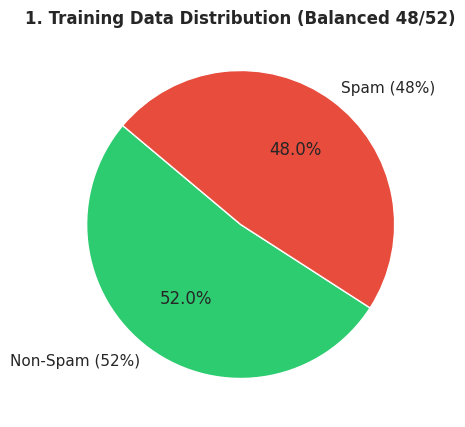

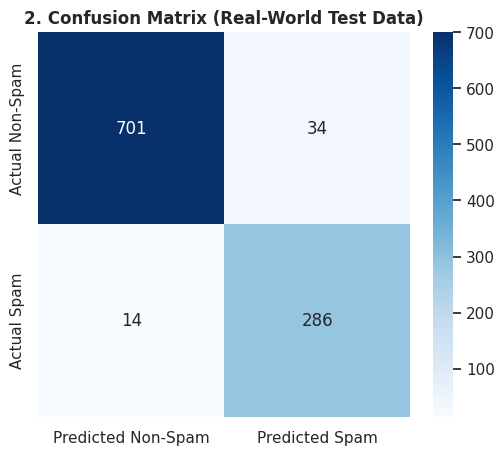

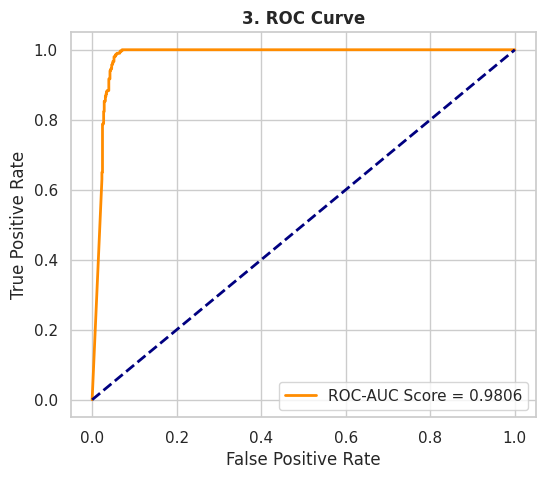

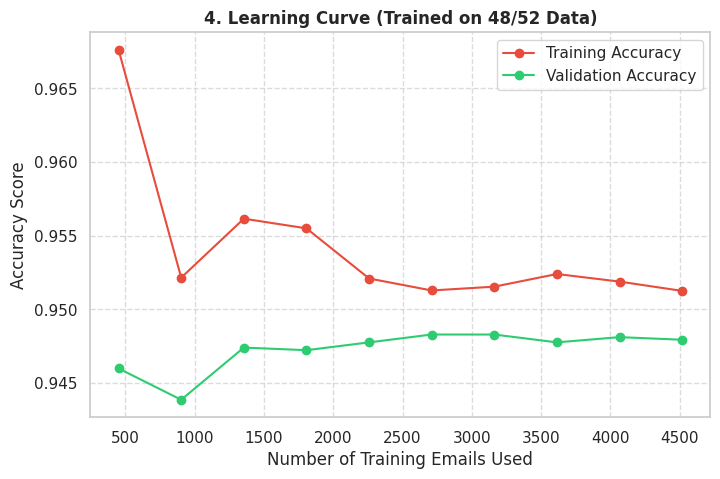

Compressing dimensions for the Scatter Diagram...


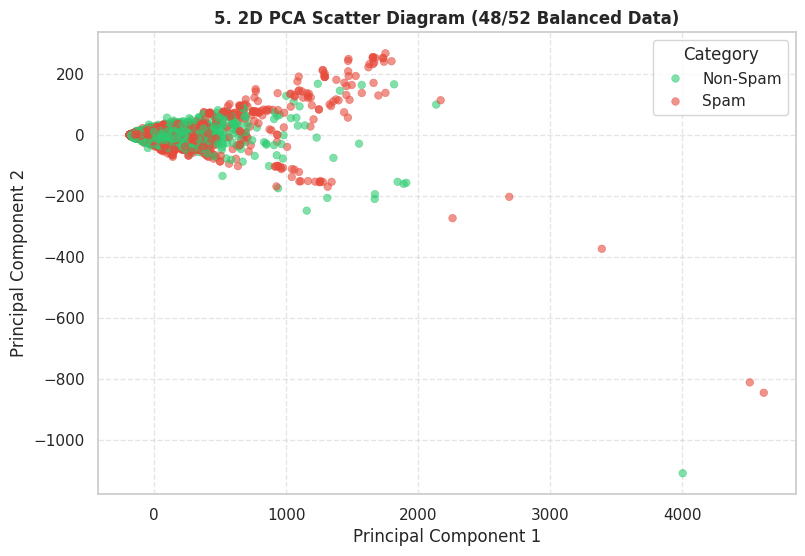

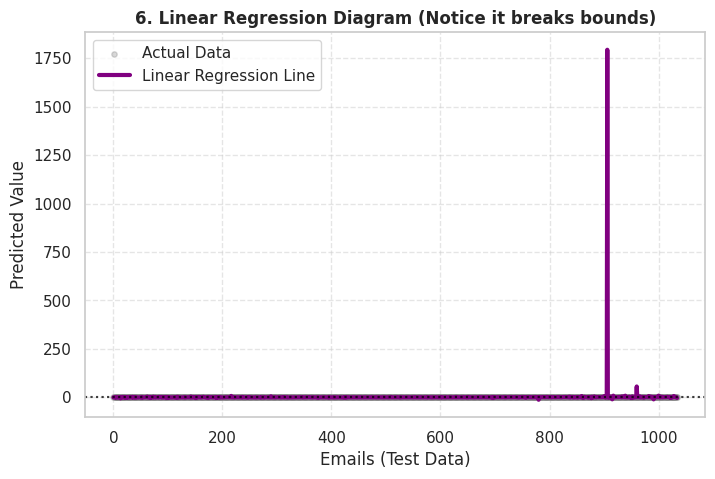

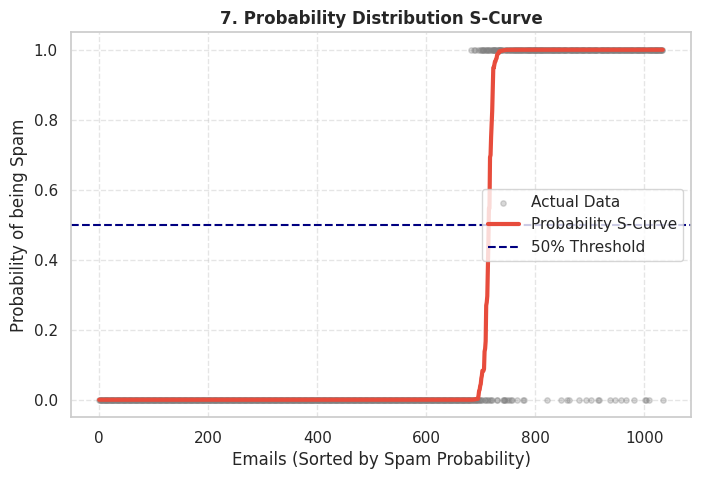

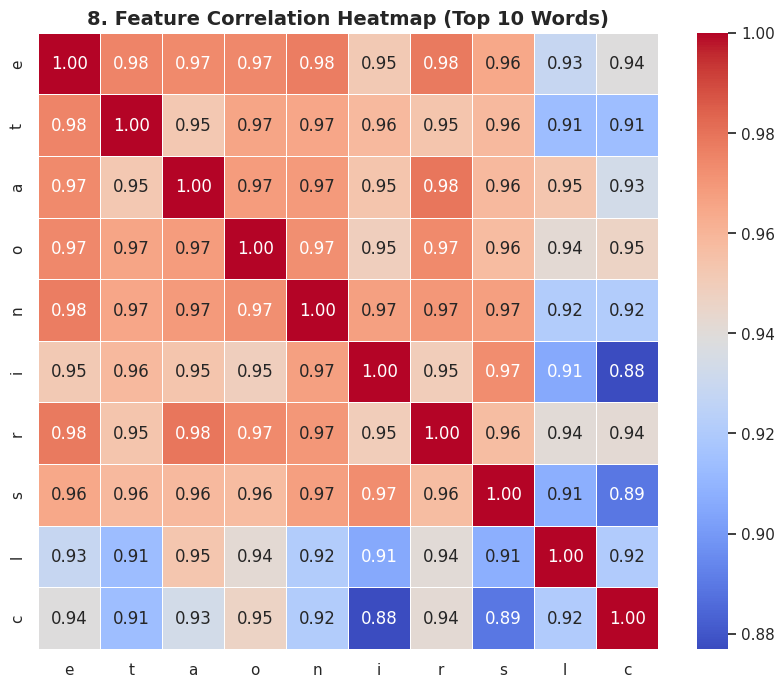

In [7]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Metrics
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             confusion_matrix, roc_curve, auc, log_loss)
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

print("Starting the Ultimate Spam Detector Pipeline...\n")

# ==========================================
# 2. LOAD AND CLEAN DATA
# ==========================================
# Using your specific Google Drive path
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/emails.csv')

if 'Email No.' in df.columns:
    df.drop(columns=['Email No.'], inplace=True)

df.dropna(inplace=True)

# ==========================================
# 3. SELECT FEATURES & SPLIT DATA FIRST
# ==========================================
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Split the data BEFORE balancing to protect the real-world test exam
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ==========================================
# 3.5 FIX THE IMBALANCE (CUSTOM 48/52 SMOTE)
# ==========================================
# SMOTE ratio generates fake spam data to achieve a 48% / 52% split
smote = SMOTE(sampling_strategy=48/52, random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# We MUST shuffle the balanced data so the fake SMOTE emails are mixed in properly
X_train_balanced, y_train_balanced = shuffle(X_train_balanced, y_train_balanced, random_state=42)

# ==========================================
# 4. TRAIN MODELS (10-BATCH ITERATION)
# ==========================================
print("Begin training...")

model = MultinomialNB()
classes = np.array([0, 1])

# Calculate batch size for 10 iterations
batch_size = len(X_train_balanced) // 10

# Train the model in 10 sequential batches to generate the requested output
for i in range(10):
    start_idx = i * batch_size
    # For the last batch, grab any remaining leftover emails
    end_idx = (i + 1) * batch_size if i < 9 else len(X_train_balanced)

    X_batch = X_train_balanced.iloc[start_idx:end_idx]
    y_batch = y_train_balanced.iloc[start_idx:end_idx]

    # Train model on this specific batch
    model.partial_fit(X_batch, y_batch, classes=classes)

    # Calculate Training Loss on the current batch
    train_probs = model.predict_proba(X_batch)
    t_loss = log_loss(y_batch, train_probs, labels=classes)

    # Calculate Validation Loss & Accuracy on the test set
    val_probs = model.predict_proba(X_test)
    v_loss = log_loss(y_test, val_probs, labels=classes)
    val_acc = accuracy_score(y_test, model.predict(X_test)) * 100

    print(f"Completed training batch {i+1} Training Loss is: {t_loss:.4f} Validation Loss is: {v_loss:.4f} Accuracy is {val_acc:.0f} %")

print("Finished Training\n")

# Secondary Linear Regression model purely for Chart 6
lin_reg = LinearRegression()
lin_reg.fit(X_train_balanced, y_train_balanced)
lin_pred = lin_reg.predict(X_test)

# ==========================================
# 5. CALCULATE METRICS & PER-CATEGORY ACCURACY
# ==========================================
# Get final predictions for the metrics
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
train_score = model.score(X_train_balanced, y_train_balanced)
test_score = model.score(X_test, y_test)
difference = train_score - test_score

# Calculate Per-Category Accuracy using the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
safe_accuracy = cm[0, 0] / (cm[0, 0] + cm[0, 1])
spam_accuracy = cm[1, 1] / (cm[1, 0] + cm[1, 1])

# ==========================================
# 6. PRINT FINAL REPORT
# ==========================================
print("====================================")
print("          FINAL REPORT              ")
print("====================================")
print(f"Total Original Emails: {len(df)}\n")

print("--- Data Balance Details ---")
print(f"Original Training Set: {sum(y_train == 0)} Safe | {sum(y_train == 1)} Spam")
print(f"Balanced Training Set: {sum(y_train_balanced == 0)} Safe | {sum(y_train_balanced == 1)} Spam")
print(f"New SMOTE Ratio:       52% Safe / 48% Spam\n")

print("--- Performance Metrics ---")
print(f"Overall Accuracy:      {accuracy * 100:.2f}%")
print(f"Overall Precision:     {precision * 100:.2f}%")
print(f"Accuracy to predict Safe (Non-Spam): {safe_accuracy * 100:.2f}%")
print(f"Accuracy to predict Spam:            {spam_accuracy * 100:.2f}%\n")

if difference > 0.05:
    print("Overfitting Check: Model may be overfitting.")
else:
    print("Overfitting Check: Model is stable and NOT overfitting.")
print("====================================\n")

# ==========================================
# 7. VISUALIZATIONS DASHBOARD (8 Charts Now)
# ==========================================
print("Generating Dashboard Charts...\n")

# CHART 1: PIE CHART
plt.figure(figsize=(5, 5))
labels = ['Non-Spam (52%)', 'Spam (48%)']
sizes = [sum(y_train_balanced == 0), sum(y_train_balanced == 1)]
colors = ['#2ecc71', '#e74c3c']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('1. Training Data Distribution (Balanced 48/52)', fontweight='bold')
plt.show()

# CHART 2: CONFUSION MATRIX
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Spam', 'Predicted Spam'],
            yticklabels=['Actual Non-Spam', 'Actual Spam'])
plt.title('2. Confusion Matrix (Real-World Test Data)', fontweight='bold')
plt.show()

# CHART 3: ROC CURVE
plt.figure(figsize=(6, 5))
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-AUC Score = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('3. ROC Curve', fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

# CHART 4: LEARNING CURVE
plt.figure(figsize=(8, 5))
train_sizes, train_scores, test_scores = learning_curve(
    MultinomialNB(), X_train_balanced, y_train_balanced, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
plt.plot(train_sizes, train_scores_mean, 'o-', color="#e74c3c", label="Training Accuracy")
plt.plot(train_sizes, test_scores_mean, 'o-', color="#2ecc71", label="Validation Accuracy")
plt.title('4. Learning Curve (Trained on 48/52 Data)', fontweight='bold')
plt.xlabel('Number of Training Emails Used')
plt.ylabel('Accuracy Score')
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# CHART 5: PCA SCATTER DIAGRAM
print("Compressing dimensions for the Scatter Diagram...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_balanced)

plt.figure(figsize=(9, 6))
scatter = sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=y_train_balanced, palette=['#2ecc71', '#e74c3c'],
    alpha=0.6, s=30, edgecolor=None
)
plt.title('5. 2D PCA Scatter Diagram (48/52 Balanced Data)', fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
handles, _ = scatter.get_legend_handles_labels()
plt.legend(handles, ['Non-Spam', 'Spam'], title='Category', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Data sorting for Charts 6 & 7
sorted_indices = np.argsort(y_prob)
sorted_probs = y_prob[sorted_indices]
sorted_lin_pred = lin_pred[sorted_indices]
sorted_actuals = y_test.values[sorted_indices]

# CHART 6: LINEAR REGRESSION DIAGRAM
plt.figure(figsize=(8, 5))
plt.scatter(range(len(y_test)), sorted_actuals, color='gray', alpha=0.3, label='Actual Data', s=15)
plt.plot(range(len(y_test)), sorted_lin_pred, color='purple', lw=3, label='Linear Regression Line')
plt.axhline(y=1.0, color='black', linestyle=':', alpha=0.5)
plt.axhline(y=0.0, color='black', linestyle=':', alpha=0.5)
plt.title('6. Linear Regression Diagram (Notice it breaks bounds)', fontweight='bold')
plt.xlabel('Emails (Test Data)')
plt.ylabel('Predicted Value')
plt.legend(loc="upper left")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# CHART 7: PROBABILITY S-CURVE
plt.figure(figsize=(8, 5))
plt.scatter(range(len(y_test)), sorted_actuals, color='gray', alpha=0.3, label='Actual Data', s=15)
plt.plot(range(len(y_test)), sorted_probs, color='#e74c3c', lw=3, label='Probability S-Curve')
plt.axhline(y=0.5, color='navy', linestyle='--', label='50% Threshold')
plt.title('7. Probability Distribution S-Curve', fontweight='bold')
plt.xlabel('Emails (Sorted by Spam Probability)')
plt.ylabel('Probability of being Spam')
plt.legend(loc="center right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# CHART 8: THE NEW FEATURE CORRELATION HEATMAP
plt.figure(figsize=(10, 8))
# Get the top 10 most used words in the entire dataset
top_10_words = X.sum().sort_values(ascending=False).head(10).index
# Calculate how strongly these specific words correlate to each other
correlation_matrix = X[top_10_words].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('8. Feature Correlation Heatmap (Top 10 Words)', fontweight='bold', fontsize=14)
plt.show()